## Import thư viện

In [56]:
# Import các thư viện cần thiết cho ML
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Đọc dữ liệu

In [57]:
# Đọc dữ liệu
columns = [
    "Age", "Gender", "Total_Bilirubin", "Direct_Bilirubin",
    "Alkaline_Phosphotase", "Alamine_Aminotransferase", "Aspartate_Aminotransferase",
    "Total_Protiens", "Albumin", "Albumin_and_Globulin_Ratio", "Liver cirrhosis"
]
df = pd.read_csv("Indian Liver Patient Dataset (ILPD).csv", header=None, names=columns)

display(df)

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Liver cirrhosis
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1
...,...,...,...,...,...,...,...,...,...,...,...
578,60,Male,0.5,0.1,500,20,34,5.9,1.6,0.37,2
579,40,Male,0.6,0.1,98,35,31,6.0,3.2,1.10,1
580,52,Male,0.8,0.2,245,48,49,6.4,3.2,1.00,1
581,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.00,1


In [58]:
df['Liver cirrhosis'] = df['Liver cirrhosis'].map({2:0, 1:1}) 

## Kiểm tra tổng quan dữ liệu

In [59]:
# Thông tin tổng quan về DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    str    
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Liver cirrhosis             583 non-null    int64  
dtypes: float64(5), int64(5), str(1)
memory usage: 50.2 KB


In [60]:
# Thống kê mô tả
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,583.0,44.746141,16.189833,4.0,33.0,45.00,58.0,90.0
Total_Bilirubin,583.0,3.298799,6.209522,0.4,0.8,1.00,2.6,75.0
Direct_Bilirubin,583.0,1.486106,2.808498,0.1,0.2,0.30,1.3,19.7
Alkaline_Phosphotase,583.0,290.576329,242.937989,63.0,175.5,208.00,298.0,2110.0
Alamine_Aminotransferase,583.0,80.713551,182.620356,10.0,23.0,35.00,60.5,2000.0
Aspartate_Aminotransferase,583.0,109.910806,288.918529,10.0,25.0,42.00,87.0,4929.0
Total_Protiens,583.0,6.483190,1.085451,2.7,5.8,6.60,7.2,9.6
Albumin,583.0,3.141852,0.795519,0.9,2.6,3.10,3.8,5.5
Albumin_and_Globulin_Ratio,579.0,0.947064,0.319592,0.3,0.7,0.93,1.1,2.8
Liver cirrhosis,583.0,0.713551,0.452490,0.0,0.0,1.00,1.0,1.0


## Phân bố target (Liver cirrhosis)

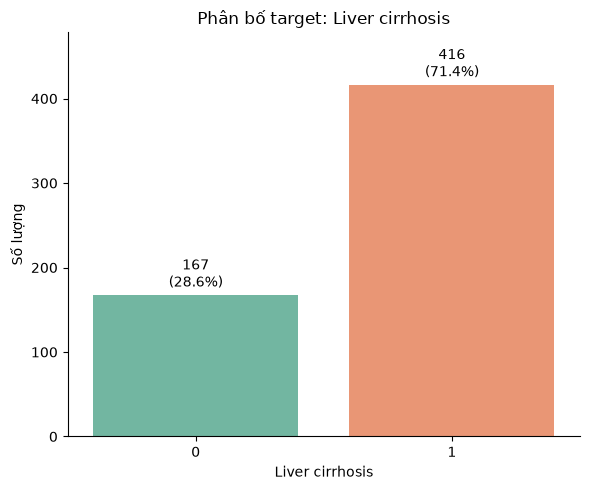

In [61]:
# Bar plot: phân bố target Liver cirrhosis (số đếm + %)
counts = df['Liver cirrhosis'].value_counts().sort_index()
pct = counts / counts.sum() * 100
labels = [f'{c}\n({p:.1f}%)' for c, p in zip(counts.values, pct.values)]

plt.figure(figsize=(6, 5))
ax = sns.barplot(
    x=counts.index.astype(str), y=counts.values,
    hue=counts.index.astype(str), palette='Set2', legend=False
)

# seaborn 0.13 tách mỗi cột thành 1 container riêng -> label từng cái
for container, lbl in zip(ax.containers, labels):
    ax.bar_label(container, labels=[lbl], padding=3)

ax.set_title('Phân bố target: Liver cirrhosis')
ax.set_xlabel('Liver cirrhosis')
ax.set_ylabel('Số lượng')
ax.set_ylim(0, counts.max() * 1.15)
sns.despine()
plt.tight_layout()
plt.show()

# Phân tích biến định tính. Quan hệ giữa Gender và target

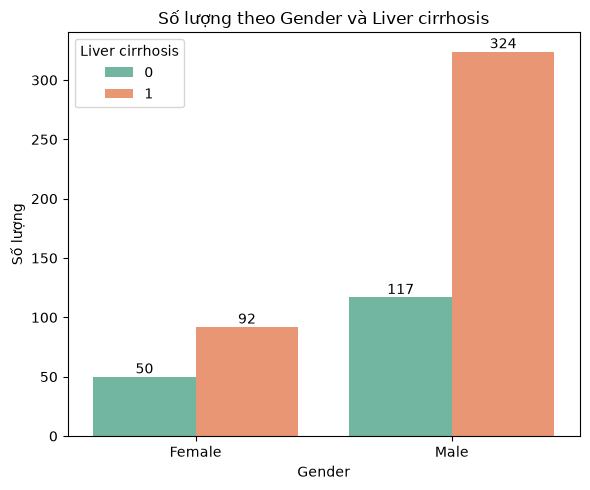

In [62]:
# Bar chart: số lượng theo Gender, phân theo target
plt.figure(figsize=(6, 5))
ax = sns.countplot(data=df, x='Gender', hue='Liver cirrhosis', palette='Set2')
ax.set_title('Số lượng theo Gender và Liver cirrhosis')
ax.set_xlabel('Gender')
ax.set_ylabel('Số lượng')
ax.legend(title='Liver cirrhosis')

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [63]:
# Kiểm định Chi-square: H0 = tỉ lệ mắc bệnh không khác nhau giữa hai giới tính
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df['Gender'], df['Liver cirrhosis'])
print("Bảng tần số quan sát:")
display(contingency)

chi2, p_value, dof, expected = chi2_contingency(contingency)

print(f"\nChi-square statistic: {chi2:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Bậc tự do: {dof}")
print("\nBảng tần số kỳ vọng (cần >= 5 để Chi-square hợp lệ):")
display(pd.DataFrame(expected, index=contingency.index, columns=contingency.columns).round(2))

alpha = 0.05
if p_value < alpha:
    print(f"\np-value ({p_value:.4f}) < {alpha} => Bác bỏ H0: có sự khác biệt về tỉ lệ mắc bệnh giữa hai giới tính.")
else:
    print(f"\np-value ({p_value:.4f}) >= {alpha} => Không đủ bằng chứng bác bỏ H0: chưa thấy khác biệt về tỉ lệ mắc bệnh giữa hai giới tính.")

Bảng tần số quan sát:


Liver cirrhosis,0,1
Gender,,
Female,50,92
Male,117,324



Chi-square statistic: 3.5466
p-value: 0.0597
Bậc tự do: 1

Bảng tần số kỳ vọng (cần >= 5 để Chi-square hợp lệ):


Liver cirrhosis,0,1
Gender,,
Female,40.68,101.32
Male,126.32,314.68



p-value (0.0597) >= 0.05 => Không đủ bằng chứng bác bỏ H0: chưa thấy khác biệt về tỉ lệ mắc bệnh giữa hai giới tính.


# Phân tích các biến định lượng

## Ma trận tương quan giữa các biến số

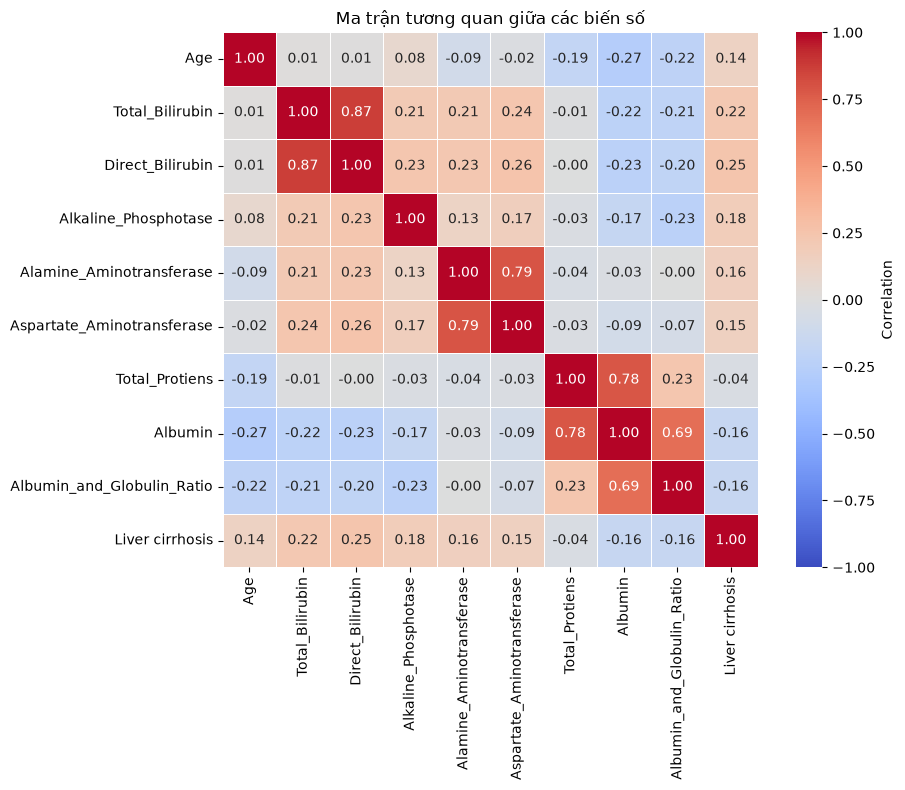

In [64]:
# Ma trận tương quan (bỏ cột Gender vì không phải số)
corr = df.drop(columns=['Gender']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    cbar_kws={'label': 'Correlation'}
)
plt.title('Ma trận tương quan giữa các biến số')
plt.tight_layout()
plt.show()

## Kiểm tra đa cộng tuyến (VIF)

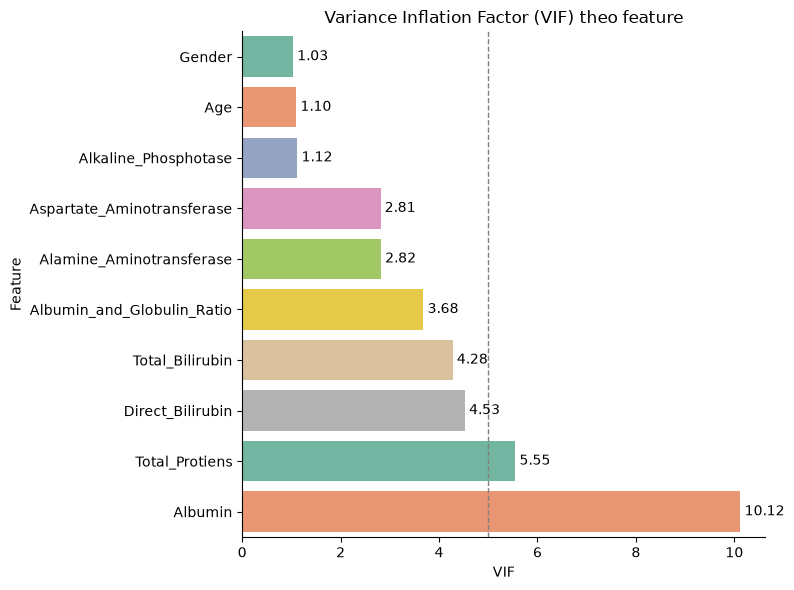

In [65]:
# VIF (Variance Inflation Factor): kiểm tra đa cộng tuyến giữa các feature
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df.drop(columns=['Liver cirrhosis']).copy()
X_vif['Gender'] = X_vif['Gender'].map({'Male': 1, 'Female': 0})
X_vif['Albumin_and_Globulin_Ratio'] = X_vif['Albumin_and_Globulin_Ratio'].fillna(
    X_vif['Albumin_and_Globulin_Ratio'].median()
)
X_vif.insert(0, 'const', 1.0)  # VIF cần cột hằng số để chuẩn xác

vif_df = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif_df = vif_df[vif_df['Feature'] != 'const'].sort_values('VIF', ascending=False).reset_index(drop=True)

# Bar plot VIF theo feature
plt.figure(figsize=(8, 6))
ax = sns.barplot(data=vif_df.sort_values('VIF'), y='Feature', x='VIF',
                 hue='Feature', palette='Set2', legend=False)
ax.axvline(5, color='gray', linestyle='--', linewidth=1)
ax.set_title('Variance Inflation Factor (VIF) theo feature')

# seaborn 0.13 tách mỗi bar thành 1 container riêng (do hue) -> label từng cái
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

sns.despine()
plt.tight_layout()
plt.show()

## Phân phối các biến số (Boxplot)

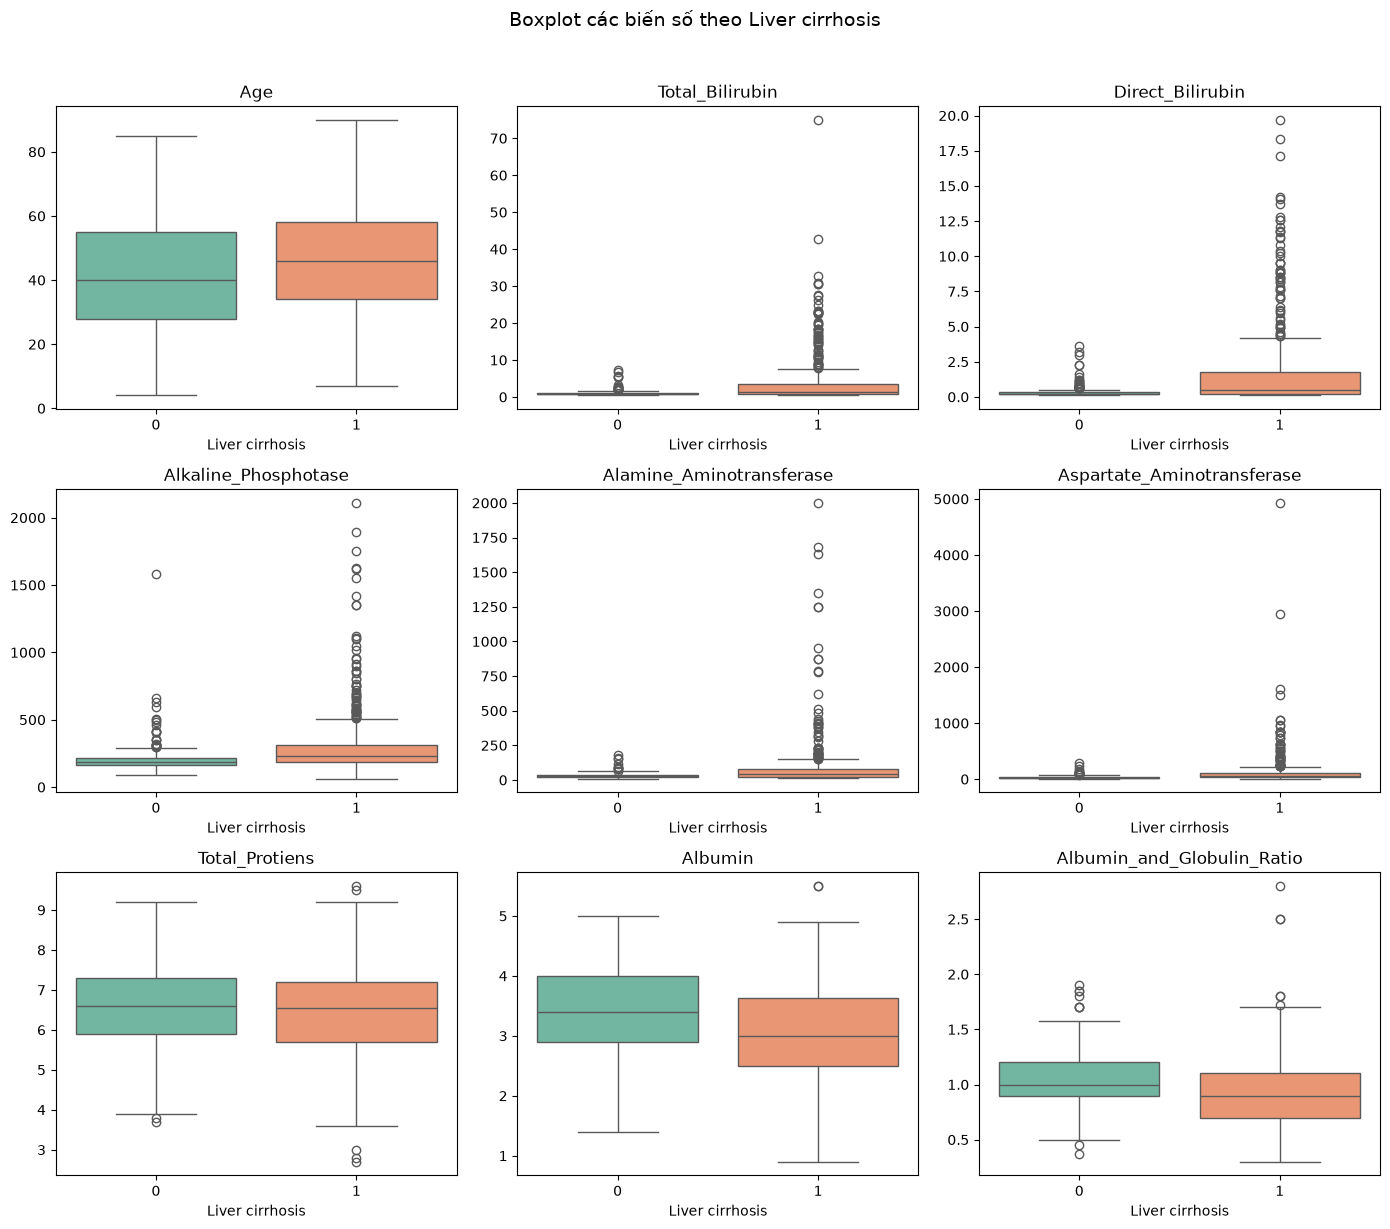

In [66]:
# Boxplot cho 9 biến số theo từng nhóm target (hue = Liver cirrhosis)
numeric_cols = [
    "Age", "Total_Bilirubin", "Direct_Bilirubin",
    "Alkaline_Phosphotase", "Alamine_Aminotransferase", "Aspartate_Aminotransferase",
    "Total_Protiens", "Albumin", "Albumin_and_Globulin_Ratio"
]
fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, x='Liver cirrhosis', y=col, hue='Liver cirrhosis',
               palette='Set2', legend=False, ax=ax)
    ax.set_title(col)
    ax.set_ylabel('')
    ax.set_xlabel('Liver cirrhosis')

plt.suptitle('Boxplot các biến số theo Liver cirrhosis', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

Đã log1p 5 biến. Bản gốc giữ ở df_raw; từ đây trở đi df là bản đã biến đổi.


,Skew gốc,Skew sau log1p
Total_Bilirubin,4.91,1.73
Direct_Bilirubin,3.21,1.69
Alkaline_Phosphotase,3.77,1.33
Alamine_Aminotransferase,6.55,1.47
Aspartate_Aminotransferase,10.55,1.23


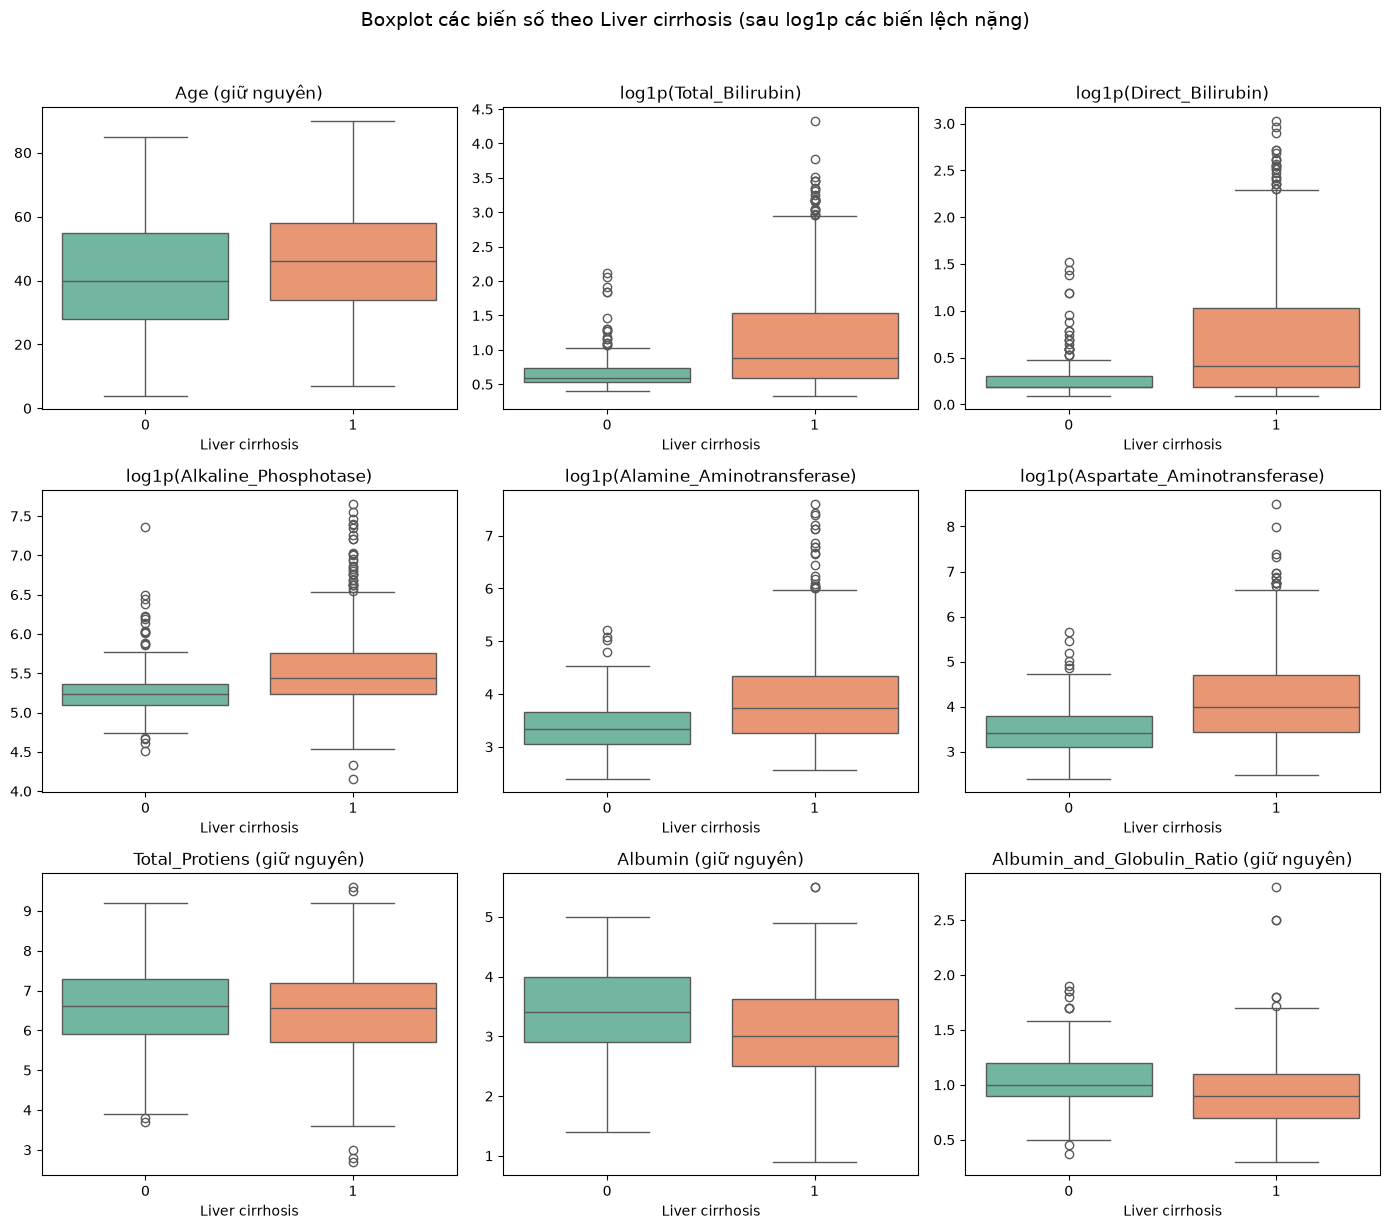

In [67]:
# Áp dụng log1p cho các biến lệch phải nặng, dùng cho toàn bộ phần còn lại của notebook.
# Dùng log1p thay vì winsorization: outlier ở đây là tín hiệu lâm sàng thật (AST~5000 = suy gan cấp)
# và nằm chủ yếu ở nhóm bệnh, nên kẹp đuôi sẽ kéo hai nhóm lại gần nhau -> mất khả năng phân biệt.
# log1p đơn điệu tăng nên bảo toàn thứ hạng (p-value Mann-Whitney không đổi) mà vẫn nén leverage.
skewed_cols = [
    "Total_Bilirubin", "Direct_Bilirubin", "Alkaline_Phosphotase",
    "Alamine_Aminotransferase", "Aspartate_Aminotransferase"
]

# Giữ bản gốc ở df_raw; luôn dựng lại df từ df_raw để chạy lại cell nhiều lần không log chồng lên nhau
if 'df_raw' not in globals():
    df_raw = df.copy()

df = df_raw.copy()
for col in skewed_cols:
    df[col] = np.log1p(df[col])

print(f"Đã log1p {len(skewed_cols)} biến. Bản gốc giữ ở df_raw; từ đây trở đi df là bản đã biến đổi.")

# Skewness trước/sau để xác nhận đuôi đã được nén
display(pd.DataFrame({
    'Skew gốc': df_raw[skewed_cols].skew(),
    'Skew sau log1p': df[skewed_cols].skew(),
}).round(2))

# Boxplot lại theo đúng bố cục cũ để so sánh trực quan với cell phía trên
fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, x='Liver cirrhosis', y=col, hue='Liver cirrhosis',
               palette='Set2', legend=False, ax=ax)
    ax.set_title(f'log1p({col})' if col in skewed_cols else f'{col} (giữ nguyên)')
    ax.set_ylabel('')
    ax.set_xlabel('Liver cirrhosis')

plt.suptitle('Boxplot các biến số theo Liver cirrhosis (sau log1p các biến lệch nặng)',
            y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

,Feature,VIF gốc,VIF log,Chênh lệch
0,Total_Bilirubin,4.28,20.72,16.44
1,Direct_Bilirubin,4.53,20.55,16.03
2,Albumin,10.12,10.62,0.49
3,Total_Protiens,5.55,5.65,0.10
4,Aspartate_Aminotransferase,2.81,4.18,1.37
5,Alamine_Aminotransferase,2.82,3.94,1.12
6,Albumin_and_Globulin_Ratio,3.68,3.75,0.07
7,Alkaline_Phosphotase,1.12,1.28,0.16
8,Age,1.10,1.10,-0.00
9,Gender,1.03,1.06,0.03


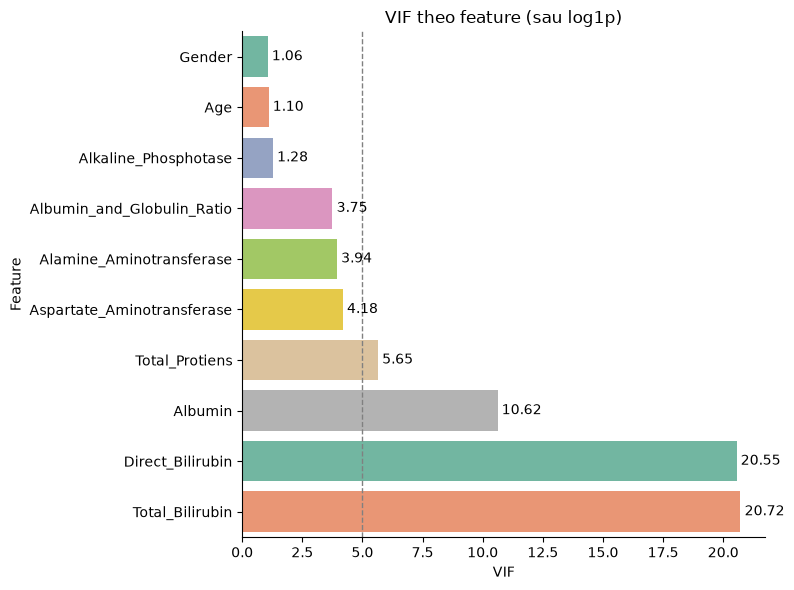

In [68]:
# VIF tính lại trên thang log: đây mới là ma trận thiết kế mà LogReg thực sự dùng.
# (Pearson/VIF không bất biến với log - khác Mann-Whitney - nên con số sẽ lệch so với bảng VIF phía trên.)
X_vif_log = df.drop(columns=['Liver cirrhosis']).copy()
X_vif_log['Gender'] = X_vif_log['Gender'].map({'Male': 1, 'Female': 0})
X_vif_log['Albumin_and_Globulin_Ratio'] = X_vif_log['Albumin_and_Globulin_Ratio'].fillna(
    X_vif_log['Albumin_and_Globulin_Ratio'].median()
)
X_vif_log.insert(0, 'const', 1.0)

vif_log_df = pd.DataFrame({
    'Feature': X_vif_log.columns,
    'VIF': [variance_inflation_factor(X_vif_log.values, i) for i in range(X_vif_log.shape[1])]
})
vif_log_df = vif_log_df[vif_log_df['Feature'] != 'const'].reset_index(drop=True)

# So sánh cạnh nhau: thang gốc vs thang log
vif_compare = (
    vif_df.merge(vif_log_df, on='Feature', suffixes=(' gốc', ' log'))
    .sort_values('VIF log', ascending=False)
    .reset_index(drop=True)
)
vif_compare['Chênh lệch'] = vif_compare['VIF log'] - vif_compare['VIF gốc']
display(vif_compare.round(2))

plt.figure(figsize=(8, 6))
ax = sns.barplot(data=vif_log_df.sort_values('VIF'), y='Feature', x='VIF',
                 hue='Feature', palette='Set2', legend=False)
ax.axvline(5, color='gray', linestyle='--', linewidth=1)
ax.set_title('VIF theo feature (sau log1p)')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

sns.despine()
plt.tight_layout()
plt.show()

## Thống kê (min, max, mean, median, std) theo nhóm target

In [69]:
# Thống kê (min, max, mean, median, std) theo từng nhóm target
# Dùng df_raw (thang đo gốc) để bảng này còn diễn giải được về mặt lâm sàng -
# nếu dùng df thì 5 cột đã log1p sẽ hiển thị theo đơn vị log.
numeric_cols = df_raw.drop(columns=['Gender', 'Liver cirrhosis']).columns

group_stats = df_raw.groupby('Liver cirrhosis')[numeric_cols].agg(
    ['min', 'max', 'mean', 'median', 'std']
).round(2).T

group_stats

Liver cirrhosis                          0        1
Age                        min        4.00     7.00
                           max       85.00    90.00
                           mean      41.24    46.15
                           median    40.00    46.00
                           std       17.00    15.65
Total_Bilirubin            min        0.50     0.40
                           max        7.30    75.00
                           mean       1.14     4.16
                           median     0.80     1.40
                           std        1.00     7.14
Direct_Bilirubin           min        0.10     0.10
                           max        3.60    19.70
                           mean       0.40     1.92
                           median     0.20     0.50
                           std        0.52     3.21
Alkaline_Phosphotase       min       90.00    63.00
                           max     1580.00  2110.00
                           mean     219.75   319.01
                           median   186.00   229.00
                           std      140.99   268.31
Alamine_Aminotransferase   min       10.00    12.00
                           max      181.00  2000.00
                           mean      33.65    99.61
                           median    27.00    41.00
                           std       25.06   212.77
Aspartate_Aminotransferase min       10.00    11.00
                           max      285.00  4929.00
                           mean      40.69   137.70
                           median    29.00    52.50
                           std       36.41   337.39
Total_Protiens             min        3.70     2.70
                           max        9.20     9.60
                           mean       6.54     6.46
                           median     6.60     6.55
                           std        1.06     1.09
Albumin                    min        1.40     0.90
                           max        5.00     5.50
                           mean       3.34     3.06
                           median     3.40     3.00
                           std        0.78     0.79
Albumin_and_Globulin_Ratio min        0.37     0.30
                           max        1.90     2.80
                           mean       1.03     0.91
                           median     1.00     0.90
                           std        0.29     0.33

## Kiểm định thống kê cho feature selection (quan hệ với target)

In [70]:
# Mann-Whitney U test cho các biến liên tục theo target
# (dùng Mann-Whitney thay vì t-test vì phần lớn feature lệch phải nặng - đã xác định ở bước skewness,
#  và t-test giả định phân phối chuẩn nên không phù hợp ở đây)
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

group0 = df[df['Liver cirrhosis'] == 0]
group1 = df[df['Liver cirrhosis'] == 1]

results = []
for col in numeric_cols:
    g0, g1 = group0[col].dropna(), group1[col].dropna()
    stat, p = mannwhitneyu(g0, g1, alternative='two-sided')
    # Rank-biserial correlation: effect size cho Mann-Whitney U (khoảng -1 đến 1)
    effect_size = 1 - (2 * stat) / (len(g0) * len(g1))
    results.append({'Feature': col, 'Test': 'Mann-Whitney U', 'Statistic': stat, 'p_value': p, 'Effect_size': effect_size})

# Gender: Cramér's V (dùng chi2 không hiệu chỉnh Yates cho effect size, chuẩn cho Cramér's V)
chi2_raw, p_raw, dof_raw, _ = chi2_contingency(contingency, correction=False)
n_gender = contingency.to_numpy().sum()
r_gender, k_gender = contingency.shape
cramers_v = np.sqrt(chi2_raw / (n_gender * (min(r_gender, k_gender) - 1)))

results.append({'Feature': 'Gender', 'Test': 'Chi-square', 'Statistic': chi2, 'p_value': p_value, 'Effect_size': cramers_v})

fs_df = pd.DataFrame(results)

# Hiệu chỉnh multiple testing (Benjamini-Hochberg FDR) vì chạy 10 kiểm định cùng lúc ở alpha=0.05
reject, p_adj, _, _ = multipletests(fs_df['p_value'], alpha=0.05, method='fdr_bh')
fs_df['p_value_fdr'] = p_adj
fs_df['Significant (FDR<0.05)'] = reject
fs_df = fs_df.sort_values('p_value').reset_index(drop=True)

fs_df

,Feature,Test,Statistic,p_value,Effect_size,p_value_fdr,Significant (FDR<0.05)
0,Aspartate_Aminotransferase,Mann-Whitney U,21035.000000,9.209662e-14,0.394432,9.209662e-13,True
1,Total_Bilirubin,Mann-Whitney U,21308.500000,2.289519e-13,0.386559,1.144759e-12,True
2,Direct_Bilirubin,Mann-Whitney U,21809.000000,7.431126e-13,0.372150,2.477042e-12,True
3,Alamine_Aminotransferase,Mann-Whitney U,21843.000000,2.332935e-12,0.371171,5.832338e-12,True
4,Alkaline_Phosphotase,Mann-Whitney U,22615.500000,4.347234e-11,0.348932,8.694469e-11,True
5,Albumin_and_Globulin_Ratio,Mann-Whitney U,42349.000000,5.812072e-06,-0.239906,9.686787e-06,True
6,Albumin,Mann-Whitney U,42141.000000,5.567004e-05,-0.213179,7.952863e-05,True
7,Age,Mann-Whitney U,28990.500000,1.774368e-03,0.165405,2.217960e-03,True
8,Gender,Chi-square,3.546649,5.966585e-02,0.082416,6.629539e-02,False
9,Total_Protiens,Mann-Whitney U,36164.500000,4.371466e-01,-0.041124,4.371466e-01,False


In [71]:
# Kết luận feature selection dựa trên p-value đã hiệu chỉnh FDR
selected_features = fs_df.loc[fs_df['Significant (FDR<0.05)'], 'Feature'].tolist()
dropped_features = fs_df.loc[~fs_df['Significant (FDR<0.05)'], 'Feature'].tolist()

print("Feature giữ lại (FDR-adjusted p < 0.05, có quan hệ với target):")
print(selected_features)
print("\nFeature loại bỏ (FDR-adjusted p >= 0.05, không đủ bằng chứng có quan hệ với target):")
print(dropped_features)

print("\nEffect size (rank-biserial / Cramér's V) theo độ mạnh giảm dần:")
print(fs_df[['Feature', 'Effect_size']].reindex(fs_df['Effect_size'].abs().sort_values(ascending=False).index).to_string(index=False))

Feature giữ lại (FDR-adjusted p < 0.05, có quan hệ với target):
['Aspartate_Aminotransferase', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alamine_Aminotransferase', 'Alkaline_Phosphotase', 'Albumin_and_Globulin_Ratio', 'Albumin', 'Age']

Feature loại bỏ (FDR-adjusted p >= 0.05, không đủ bằng chứng có quan hệ với target):
['Gender', 'Total_Protiens']

Effect size (rank-biserial / Cramér's V) theo độ mạnh giảm dần:
                   Feature  Effect_size
Aspartate_Aminotransferase     0.394432
           Total_Bilirubin     0.386559
          Direct_Bilirubin     0.372150
  Alamine_Aminotransferase     0.371171
      Alkaline_Phosphotase     0.348932
Albumin_and_Globulin_Ratio    -0.239906
                   Albumin    -0.213179
                       Age     0.165405
                    Gender     0.082416
            Total_Protiens    -0.041124


## Xây dựng mô hình: Logistic Regression (SMOTE)

In [72]:
# Chuẩn bị dữ liệu: bỏ Direct_Bilirubin (r=0.87 với Total_Bilirubin), Gender và Total_Protiens
# (không có ý nghĩa thống kê với target - FDR p>=0.05 ở bước feature selection); giữ Age
df_model = df.drop(columns=['Direct_Bilirubin', 'Gender', 'Total_Protiens']).copy()
df_model['Albumin_and_Globulin_Ratio'] = df_model['Albumin_and_Globulin_Ratio'].fillna(
    df_model['Albumin_and_Globulin_Ratio'].median()
)

X = df_model.drop(columns=['Liver cirrhosis'])
y = df_model['Liver cirrhosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("\nPhân bố target train (trước SMOTE):")
print(y_train.value_counts())

Train: (466, 7), Test: (117, 7)

Phân bố target train (trước SMOTE):
Liver cirrhosis
1    333
0    133
Name: count, dtype: int64


In [73]:
# Áp dụng SMOTE (chỉ trên tập train, không đụng vào tập test để tránh rò rỉ dữ liệu)
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Phân bố target train (sau SMOTE):")
print(y_train_sm.value_counts())

Phân bố target train (sau SMOTE):
Liver cirrhosis
1    333
0    333
Name: count, dtype: int64


In [74]:
# Huấn luyện Logistic Regression trên dữ liệu đã SMOTE
from sklearn.linear_model import LogisticRegression

# Logistic Regression cần scale feature (khác thang đo lớn giữa các biến)
scaler = StandardScaler()
X_train_sm_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_sm_scaled, y_train_sm)

y_pred_log = log_reg.predict(X_test_scaled)

print("Đã huấn luyện xong Logistic Regression.")

Đã huấn luyện xong Logistic Regression.


In [75]:
# Confusion matrix và classification report cho Logistic Regression
models_pred = {'Logistic Regression': y_pred_log}

for name, y_pred in models_pred.items():
    print(f"===== {name} =====")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Không bệnh (0)', 'Có bệnh (1)']))
    print()

===== Logistic Regression =====
Confusion Matrix:
[[28  6]
 [24 59]]

Classification Report:
                precision    recall  f1-score   support

Không bệnh (0)       0.54      0.82      0.65        34
   Có bệnh (1)       0.91      0.71      0.80        83

      accuracy                           0.74       117
     macro avg       0.72      0.77      0.72       117
  weighted avg       0.80      0.74      0.75       117




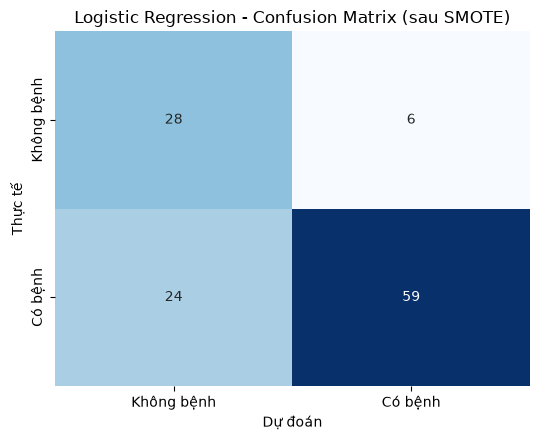

In [76]:
# Trực quan Confusion Matrix
cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5.5, 4.5))
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                 xticklabels=['Không bệnh', 'Có bệnh'], yticklabels=['Không bệnh', 'Có bệnh'])
ax.set_title('Logistic Regression - Confusion Matrix (sau SMOTE)')
ax.set_xlabel('Dự đoán')
ax.set_ylabel('Thực tế')
plt.tight_layout()
plt.show()

In [77]:
# Bảng metrics tổng hợp cho Logistic Regression
rows = []
for name, y_pred in models_pred.items():
    report = classification_report(y_test, y_pred, target_names=['0', '1'], output_dict=True)
    rows.append({
        'Model': name,
        'Accuracy': report['accuracy'],
        'Precision (0)': report['0']['precision'],
        'Recall (0)': report['0']['recall'],
        'F1 (0)': report['0']['f1-score'],
        'Precision (1)': report['1']['precision'],
        'Recall (1)': report['1']['recall'],
        'F1 (1)': report['1']['f1-score'],
        'Macro F1': report['macro avg']['f1-score'],
    })

compare_df = pd.DataFrame(rows).set_index('Model').round(3)
compare_df

,Accuracy,Precision (0),Recall (0),F1 (0),Precision (1),Recall (1),F1 (1),Macro F1
Model,,,,,,,,
Logistic Regression,0.744,0.538,0.824,0.651,0.908,0.711,0.797,0.724


## Điều chỉnh ngưỡng phân loại để ưu tiên recall lớp "có bệnh" (≥ 0.75)

In [107]:
# Ngưỡng mặc định (0.5) tối ưu cho độ chính xác tổng thể, không ưu tiên riêng lớp nào.
# Ở đây ta hạ ngưỡng quyết định để đạt recall >= TARGET_RECALL cho lớp "có bệnh" (1) - chấp nhận
# đánh đổi: nhiều người khỏe mạnh (0) bị dự đoán nhầm thành có bệnh, để không bỏ sót ca bệnh thật.
from sklearn.metrics import precision_recall_curve

TARGET_RECALL = 0.8  # chỉnh ở đây nếu muốn đổi mức recall mục tiêu

def find_threshold_for_recall(y_true, y_proba, target_recall=TARGET_RECALL):
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    valid = recall[:-1] >= target_recall
    if not valid.any():
        return thresholds.min(), recall[:-1].max()
    idx = np.where(valid)[0]
    best_idx = idx[np.argmax(thresholds[idx])]  # ngưỡng lớn nhất vẫn đạt recall mục tiêu -> precision tốt nhất có thể
    return thresholds[best_idx], recall[best_idx]

proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]

models_pred_tuned = {}
for name, proba in [('Logistic Regression', proba_log)]:
    thr, achieved_recall = find_threshold_for_recall(y_test, proba, target_recall=TARGET_RECALL)
    y_pred_tuned = (proba >= thr).astype(int)
    models_pred_tuned[name] = y_pred_tuned

    print(f"===== {name} (ngưỡng = {thr:.3f}, recall đạt được = {achieved_recall:.3f}) =====")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_tuned))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_tuned, target_names=['Không bệnh (0)', 'Có bệnh (1)']))
    print()

===== Logistic Regression (ngưỡng = 0.452, recall đạt được = 0.807) =====
Confusion Matrix:
[[28  6]
 [16 67]]

Classification Report:
                precision    recall  f1-score   support

Không bệnh (0)       0.64      0.82      0.72        34
   Có bệnh (1)       0.92      0.81      0.86        83

      accuracy                           0.81       117
     macro avg       0.78      0.82      0.79       117
  weighted avg       0.84      0.81      0.82       117




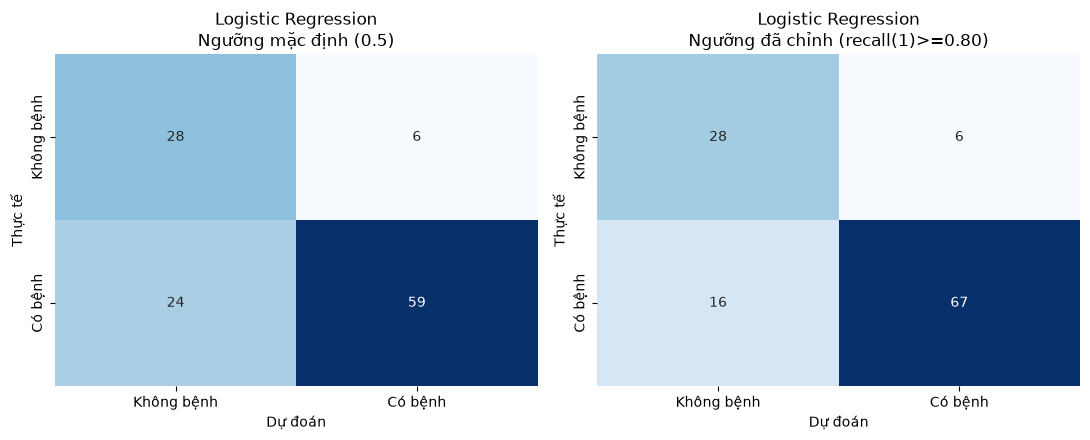

Accuracy  Recall (0)  Recall (1)  \
Model               Ngưỡng                                                      
Logistic Regression Mặc định (0.5)              0.744       0.824       0.711   
                    Đã chỉnh (recall>=0.80)     0.812       0.824       0.807   

                                             Precision (1)  Macro F1  
Model               Ngưỡng                                            
Logistic Regression Mặc định (0.5)                   0.908     0.724  
                    Đã chỉnh (recall>=0.80)          0.918     0.788

In [104]:
# So sánh trực quan: ngưỡng mặc định (0.5) vs ngưỡng đã chỉnh (recall >= TARGET_RECALL)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (title, y_pred) in zip(axes, [('Ngưỡng mặc định (0.5)', y_pred_log),
                                       (f'Ngưỡng đã chỉnh (recall(1)>={TARGET_RECALL:.2f})', models_pred_tuned['Logistic Regression'])]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
               xticklabels=['Không bệnh', 'Có bệnh'], yticklabels=['Không bệnh', 'Có bệnh'], ax=ax)
    ax.set_title(f'Logistic Regression\n{title}')
    ax.set_xlabel('Dự đoán')
    ax.set_ylabel('Thực tế')
plt.tight_layout()
plt.show()

# Bảng so sánh metrics: mặc định vs đã chỉnh ngưỡng
rows = []
for name in models_pred:
    for variant, y_pred in [('Mặc định (0.5)', models_pred[name]),
                            (f'Đã chỉnh (recall>={TARGET_RECALL:.2f})', models_pred_tuned[name])]:
        report = classification_report(y_test, y_pred, target_names=['0', '1'], output_dict=True)
        rows.append({
            'Model': name, 'Ngưỡng': variant,
            'Accuracy': report['accuracy'],
            'Recall (0)': report['0']['recall'],
            'Recall (1)': report['1']['recall'],
            'Precision (1)': report['1']['precision'],
            'Macro F1': report['macro avg']['f1-score'],
        })

pd.DataFrame(rows).set_index(['Model', 'Ngưỡng']).round(3)